# **Exploratory Data Analysis**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_smk_drnk = pd.read_csv('smoking_driking_dataset_Ver01.csv')

In [3]:
df_smk_drnk.head()

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N


## **Dataset Overview**

The dataset consists of **991,346 observations** and **24 variables**.

- **Data Completeness:** All variables are fully populated with no missing
- **Data Types:**
  - **int64:** 3 variables (e.g., age, height, weight)
  - **float64:** 19 variables (e.g., waistline, cholesterol levels, blood pressure)
  - **object:** 2 variables (e.g., sex, DRK_YN) values.
- **Next Steps:** Further investigation is needed to ensure:
  - **Data Quality:** Check for consistency in categorical values.
  - **Outliers:** Identify and handle any potential outliers.

We will proceed with a thorough analysis to ensure the data's reliability and readiness for further processing.

In [4]:
df_smk_drnk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  float64
 16  hemoglobin        99

### **Converting Object Variables to Categorical Types**

In this dataset, converting object variables to categorical types is a crucial step for efficient data handling and analysis. This conversion is essential for the following reasons:

- **Memory Optimization:** Converting object types to categorical reduces memory usage significantly.
- **Ease of Analysis:** Categorical data simplifies statistical analysis and modeling processes.
- **Discrete Value Representation:** Categorical variables represent discrete values, which is particularly important for:
  - **Group-Wise Operations:** Facilitates operations and aggregations based on categories.
  - **Machine Learning Models:** Enables the creation of dummy variables and improves model performance.

Variables such as `sex`, `SMK_stat_type_cd`, and `DRK_YN` are prime candidates for this conversion.

**SEX**

In [5]:
df_smk_drnk['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [6]:
# Map original values to new values
df_smk_drnk['sex'] = df_smk_drnk['sex'].map({'Male': 'M', 'Female': 'F'})
# Convert column to categorical type
df_smk_drnk['sex'] = pd.Categorical(df_smk_drnk['sex'], categories=['M', 'F'], ordered=True)

**SMK_stat_type_cd - Smoking state, 1(never), 2(used to smoke but quit), 3(still smoke)**

In [7]:
# Convert 'SMK_stat_type_cd' from float to integer
df_smk_drnk['SMK_stat_type_cd'] = df_smk_drnk['SMK_stat_type_cd'].fillna(0).astype(int)
df_smk_drnk['SMK_stat_type_cd'].unique()

array([1, 3, 2])

In [8]:
# Convert 'SMK_stat_type_cd' to categorical
smk_categories = sorted(df_smk_drnk['SMK_stat_type_cd'].unique())
df_smk_drnk['SMK_stat_type_cd'] = pd.Categorical(df_smk_drnk['SMK_stat_type_cd'], categories=smk_categories, ordered=True)

**DRK_YN	(Drinker or Not)**

In [9]:
df_smk_drnk['DRK_YN'].unique()

array(['Y', 'N'], dtype=object)

In [10]:
df_smk_drnk['DRK_YN'] = pd.Categorical(df_smk_drnk['DRK_YN'], categories=['Y', 'N'], ordered=False)

In [11]:
df_smk_drnk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   sex               991346 non-null  category
 1   age               991346 non-null  int64   
 2   height            991346 non-null  int64   
 3   weight            991346 non-null  int64   
 4   waistline         991346 non-null  float64 
 5   sight_left        991346 non-null  float64 
 6   sight_right       991346 non-null  float64 
 7   hear_left         991346 non-null  float64 
 8   hear_right        991346 non-null  float64 
 9   SBP               991346 non-null  float64 
 10  DBP               991346 non-null  float64 
 11  BLDS              991346 non-null  float64 
 12  tot_chole         991346 non-null  float64 
 13  HDL_chole         991346 non-null  float64 
 14  LDL_chole         991346 non-null  float64 
 15  triglyceride      991346 non-null  float64 
 16  he

In [12]:
df_smk_drnk.describe()

,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,DBP,...,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
count,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,...,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000
mean,47.614491,162.240625,63.284050,81.233358,0.980834,0.978429,1.031495,1.030476,122.432498,76.052627,...,195.557020,56.936800,113.037692,132.141751,14.229824,1.094224,0.860467,25.989308,25.755051,37.136347
std,14.181339,9.282957,12.514241,11.850323,0.605949,0.604774,0.174650,0.171892,14.543148,9.889365,...,38.660155,17.238479,35.842812,102.196985,1.584929,0.437724,0.480530,23.493386,26.308599,50.424153
min,20.000000,130.000000,25.000000,8.000000,0.100000,0.100000,1.000000,1.000000,67.000000,32.000000,...,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,1.000000,1.000000
25%,35.000000,155.000000,55.000000,74.100000,0.700000,0.700000,1.000000,1.000000,112.000000,70.000000,...,169.000000,46.000000,89.000000,73.000000,13.200000,1.000000,0.700000,19.000000,15.000000,16.000000
50%,45.000000,160.000000,60.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,193.000000,55.000000,111.000000,106.000000,14.300000,1.000000,0.800000,23.000000,20.000000,23.000000
75%,60.000000,170.000000,70.000000,87.800000,1.200000,1.200000,1.000000,1.000000,131.000000,82.000000,...,219.000000,66.000000,135.000000,159.000000,15.400000,1.000000,1.000000,28.000000,29.000000,39.000000
max,85.000000,190.000000,140.000000,999.000000,9.900000,9.900000,2.000000,2.000000,273.000000,185.000000,...,2344.000000,8110.000000,5119.000000,9490.000000,25.000000,6.000000,98.000000,9999.000000,7210.000000,999.000000


### **Analysis of categorical variables**


In [13]:
df_smk_drnk.describe()

,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,DBP,...,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
count,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,...,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000
mean,47.614491,162.240625,63.284050,81.233358,0.980834,0.978429,1.031495,1.030476,122.432498,76.052627,...,195.557020,56.936800,113.037692,132.141751,14.229824,1.094224,0.860467,25.989308,25.755051,37.136347
std,14.181339,9.282957,12.514241,11.850323,0.605949,0.604774,0.174650,0.171892,14.543148,9.889365,...,38.660155,17.238479,35.842812,102.196985,1.584929,0.437724,0.480530,23.493386,26.308599,50.424153
min,20.000000,130.000000,25.000000,8.000000,0.100000,0.100000,1.000000,1.000000,67.000000,32.000000,...,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,1.000000,1.000000
25%,35.000000,155.000000,55.000000,74.100000,0.700000,0.700000,1.000000,1.000000,112.000000,70.000000,...,169.000000,46.000000,89.000000,73.000000,13.200000,1.000000,0.700000,19.000000,15.000000,16.000000
50%,45.000000,160.000000,60.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,193.000000,55.000000,111.000000,106.000000,14.300000,1.000000,0.800000,23.000000,20.000000,23.000000
75%,60.000000,170.000000,70.000000,87.800000,1.200000,1.200000,1.000000,1.000000,131.000000,82.000000,...,219.000000,66.000000,135.000000,159.000000,15.400000,1.000000,1.000000,28.000000,29.000000,39.000000
max,85.000000,190.000000,140.000000,999.000000,9.900000,9.900000,2.000000,2.000000,273.000000,185.000000,...,2344.000000,8110.000000,5119.000000,9490.000000,25.000000,6.000000,98.000000,9999.000000,7210.000000,999.000000


**SEX DISTRIBUTION**

- **M (Male):** 526,415 individuals.
- **F (Female):** 464,931 individuals.

**Interpretation:** The dataset has a fairly balanced gender distribution, with a slightly higher number of males than females. This balance is beneficial for gender-specific analysis, as it minimizes the risk of gender bias in the results.

In [14]:
sex_counts = df_smk_drnk['sex'].value_counts()
print(sex_counts)

sex
M    526415
F    464931
Name: count, dtype: int64


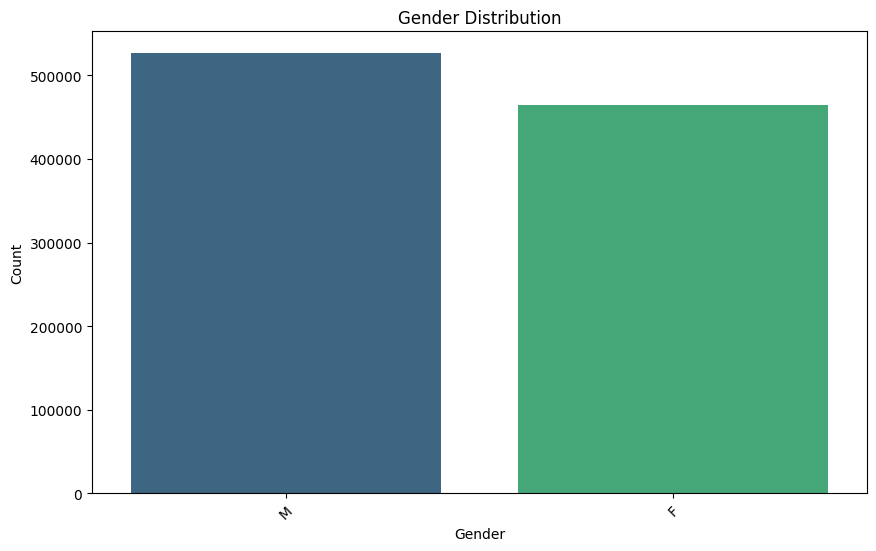

In [15]:
# Create a DataFrame for the gender counts to use with hue
sex_df = sex_counts.reset_index()
sex_df.columns = ['Gender', 'Count']

# Plot for sex counts
plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='Count', data=sex_df, hue='Gender', palette='viridis', dodge=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Smoking Status (SMK_stat_type_cd):**
- **(Never smoked):** 602,441 individuals.
- **(still smoke):** 213,954 individuals.
- **(Used to smoke but quit):** 174,951 individuals.

**Interpretation:** The majority of individuals (about 60.8%) in the dataset have never smoked. About 21.6% are current smokers, while 17.6% used to smoke but quit. This distribution allows for detailed analysis of smoking habits and their impact on health outcomes.



In [16]:
smoking_counts = df_smk_drnk['SMK_stat_type_cd'].value_counts()
print(smoking_counts)

SMK_stat_type_cd
1    602441
3    213954
2    174951
Name: count, dtype: int64


C:\Users\Jdela\AppData\Local\Temp\ipykernel_33340\2645181061.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Smoking Status', loc='upper right', frameon=False)


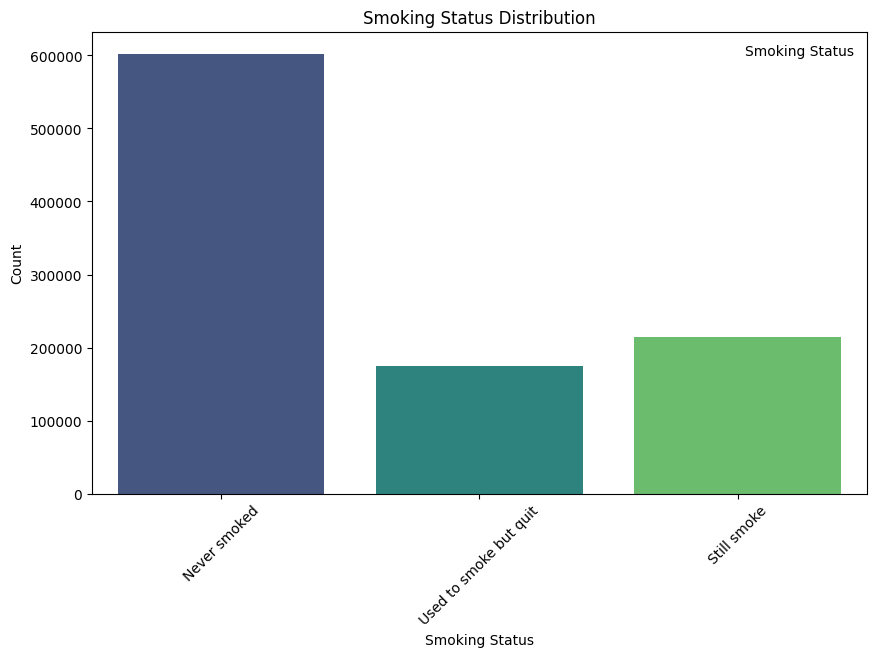

In [17]:
# Create a DataFrame for the smoking status counts to use with hue
smoking_df = smoking_counts.reset_index()
smoking_df.columns = ['Smoking Status', 'Count']

custom_labels = {
    1: 'Never smoked',
    3: 'Still smoke',
    2: 'Used to smoke but quit'
}

# Apply custom labels to the DataFrame
smoking_df['Smoking Status'] = smoking_df['Smoking Status'].map(custom_labels)


# Plot for smoking status counts
plt.figure(figsize=(10, 6))
sns.barplot(x='Smoking Status', y='Count', data=smoking_df, hue='Smoking Status', palette='viridis', dodge=False)
plt.title('Smoking Status Distribution')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Smoking Status', loc='upper right', frameon=False)
plt.show()

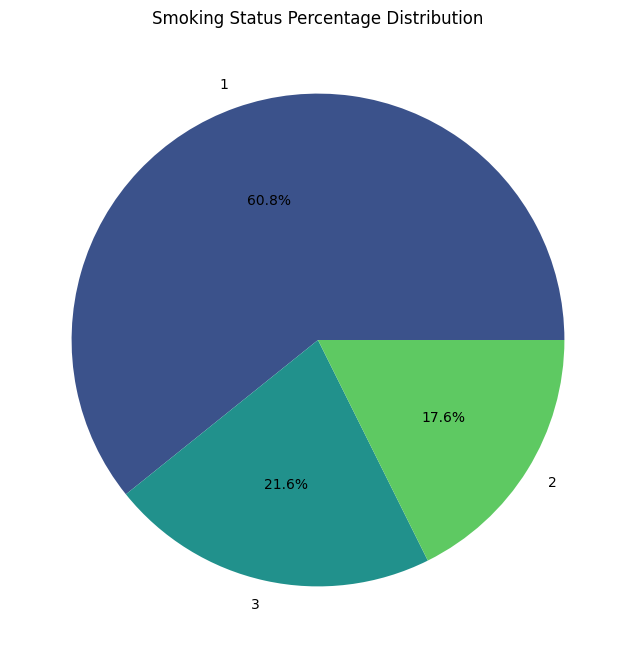

In [18]:
# Frequency counts
smoking_counts = df_smk_drnk['SMK_stat_type_cd'].value_counts()

#percentages
smoking_percentages = (smoking_counts / smoking_counts.sum()) * 100

smoking_percentages_df = smoking_percentages.reset_index()
smoking_percentages_df.columns = ['Smoking Status', 'Percentage']

plt.figure(figsize=(8, 8))
plt.pie(smoking_percentages, labels=smoking_percentages.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(smoking_percentages)))
plt.title('Smoking Status Percentage Distribution')
plt.show()

**Drinking Status (DRK_YN)**
- **N (Non-drinkers):** 495,858 individuals.
- **Y (Drinkers):** 495,488 individuals.

**Interpretation:** The dataset is almost perfectly balanced in terms of drinking status, with an almost equal split between drinkers and non-drinkers. This balance provides a solid foundation for comparative analysis between these two groups.

In [19]:
drinking_counts = df_smk_drnk['DRK_YN'].value_counts()
print(drinking_counts)

DRK_YN
N    495858
Y    495488
Name: count, dtype: int64


C:\Users\Jdela\AppData\Local\Temp\ipykernel_33340\1675206571.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Drinking Status', loc='upper right', frameon=False)


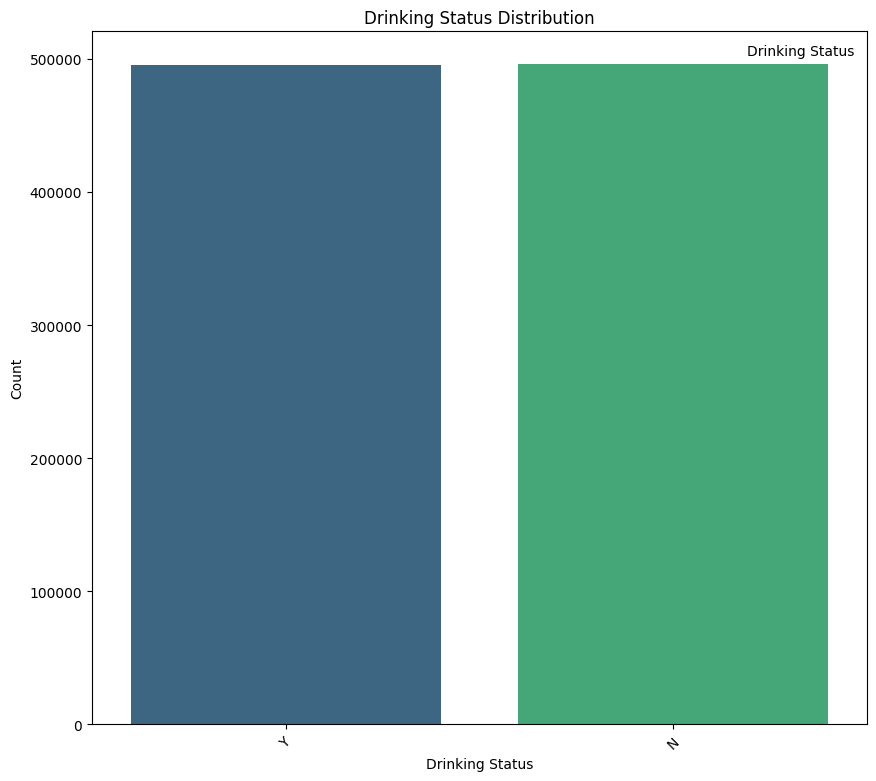

In [20]:
# Create a DataFrame for the drinking status counts to use with hue
drinking_df = drinking_counts.reset_index()
drinking_df.columns = ['Drinking Status', 'Count']

# Plot for drinking status counts
plt.figure(figsize=(10, 9))
sns.barplot(x='Drinking Status', y='Count', data=drinking_df, hue='Drinking Status', palette='viridis', dodge=False)
plt.title('Drinking Status Distribution')
plt.xlabel('Drinking Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Drinking Status', loc='upper right', frameon=False)
plt.show()

**Age Distribution by Drinking Status**
- Drinking appears to peak between the ages of 30 and 50, with a gradual decline starting around 50 years old.

- The number of non-drinkers increases with age, particularly after 60 years, potentially due to health concerns or lifestyle changes.

- Younger individuals (ages 20–30) show a noticeable presence of drinkers, but non-drinkers remain relatively close in count.

- Around ages 55–60, the proportion of non-drinkers surpasses that of drinkers. This shift suggests a critical age where drinking behavior declines substantially.


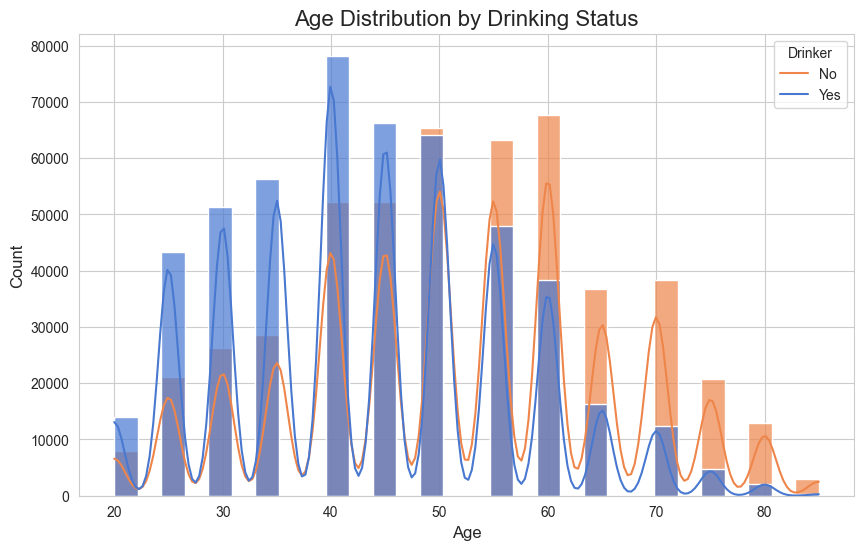

In [21]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(data=df_smk_drnk, x="age", hue="DRK_YN", kde=True,
             palette="muted", bins=30, alpha=0.7)
plt.title("Age Distribution by Drinking Status", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Drinker", labels=["No", "Yes"])
plt.show()

**Age Distribution by Smoking Status**

- The "Still Smoking" category (blue) has the highest density across all age groups, indicating that a significant portion of the population continues to smoke.

- The "Never Smoked" category (green) has a relatively consistent but lower density compared to "Still Smoking." This suggests that a smaller but steady group of individuals never pick up smoking across all ages.

- The "Quit Smoking" category (orange) appears to increase slightly with age, especially beyond 40 years. This may indicate that older individuals are more likely to quit smoking, possibly due to health concerns or lifestyle changes.

- Younger individuals (ages 20–30) show fewer instances of smoking (both active and quit), likely reflecting greater awareness or a shift in social norms discouraging smoking in recent years.

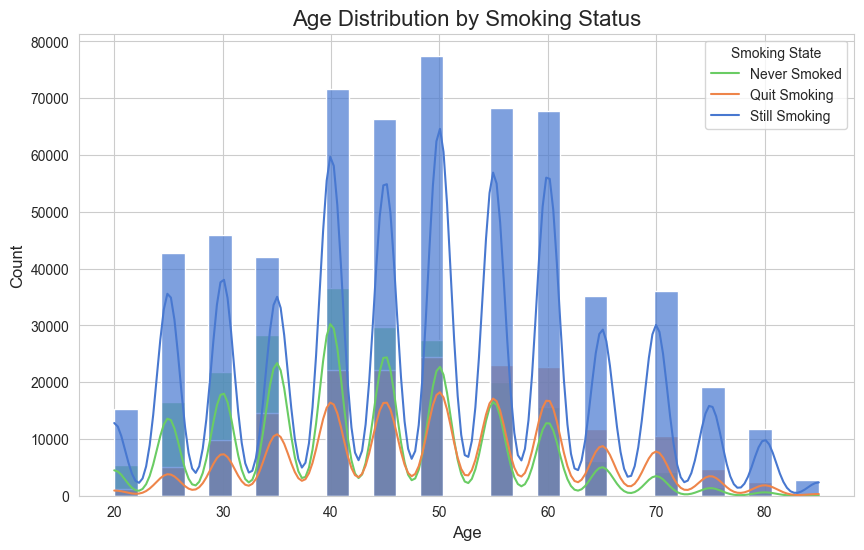

In [22]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(data=df_smk_drnk, x="age", hue="SMK_stat_type_cd", kde=True,
             palette="muted", bins=30, alpha=0.7)
plt.title("Age Distribution by Smoking Status", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Smoking State", labels=["Never Smoked", "Quit Smoking", "Still Smoking"])
plt.show()

**Pairplot of Key Body Signals by Drinking Status**

- Both drinkers and non-drinkers have similar hemoglobin distributions, with minor differences visible in density. This suggests hemoglobin might not strongly differentiate drinkers from non-drinkers.

- Drinkers have a broader range and significantly higher values for gamma-GTP compared to non-drinkers. This confirms gamma-GTP as a potential key indicator for distinguishing drinkers due to its known association with liver stress from alcohol consumption.

- Most values for serum creatinine are concentrated at lower levels for both groups, with no significant visual separation between drinkers and non-drinkers.

RELATIONSHIPS:

- Hemoglobin vs. Gamma-GTP: No clear relationship is observed, but drinkers have more outliers for gamma-GTP at certain hemoglobin levels.

- Gamma-GTP vs. Serum Creatinine: There is no evident correlation, as serum creatinine values remain low regardless of gamma-GTP levels.


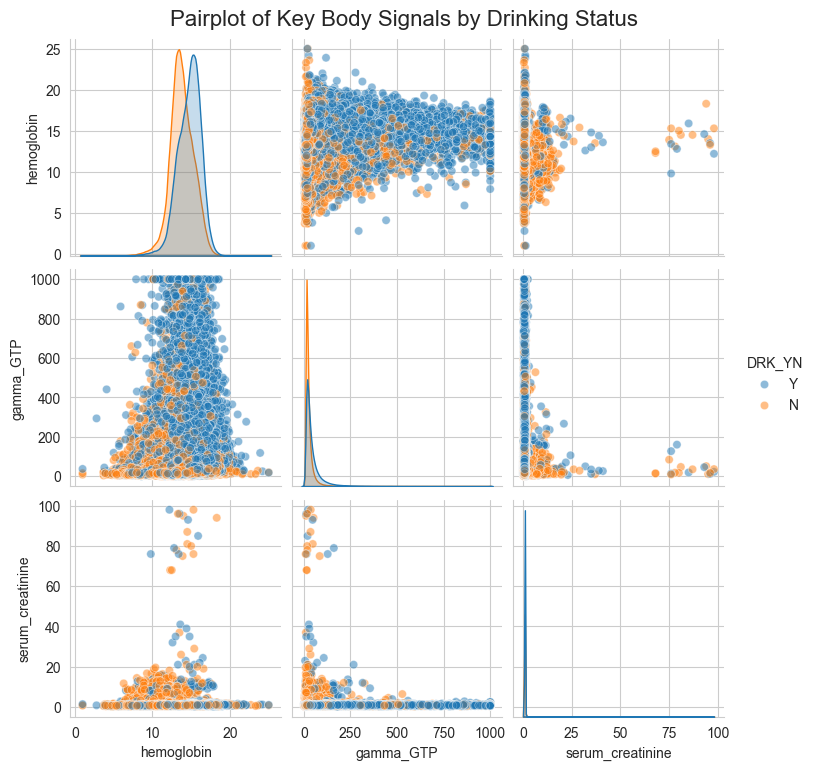

In [23]:
key_features = ["hemoglobin", "gamma_GTP", "serum_creatinine", "SMK_stat_type_cd", "DRK_YN"]
sns.pairplot(df_smk_drnk[key_features], hue="DRK_YN", palette="tab10", diag_kind="kde", plot_kws={'alpha': 0.5})
plt.suptitle("Pairplot of Key Body Signals by Drinking Status", y=1.02, fontsize=16)
plt.show()

**Pairplot of Key Body Signals by Smoking Status**

- Never Smokers (1): Never-smokers generally have the highest hemoglobin levels, which is expected as they are not exposed to the harmful effects of smoking.

- Former Smokers (2): Former smokers seem to have intermediate hemoglobin levels between current smokers and never-smokers. This suggests that quitting smoking can lead to some recovery in hemoglobin levels over time.

- Smokers (3): Smokers tend to have slightly lower hemoglobin levels compared to never-smokers and former smokers. This could be due to various factors, including reduced oxygen-carrying capacity in the blood due to carbon monoxide exposure.

- Gamma-GTP: There's a clear difference in distribution. The "still smoke" group has a higher concentration of gamma-GTP compared to the other two groups. This could indicate potential liver damage or dysfunction associated with smoking.

- Serum Creatinine: The distribution is similar across all groups, suggesting no significant impact of smoking status on kidney function.

RELATIONSHIPS

- Hemoglobin vs. Gamma-GTP: No clear relationship is visible.
- Hemoglobin vs. Serum Creatinine: No clear relationship is visible.
- Hemoglobin vs. Triglycerides: No clear relationship is visible.
- Gamma-GTP vs. Serum Creatinine: No clear relationship is visible.
- Gamma-GTP vs. Triglycerides: No clear relationship is visible.
- Serum Creatinine vs. Triglycerides: No clear relationship is visible.


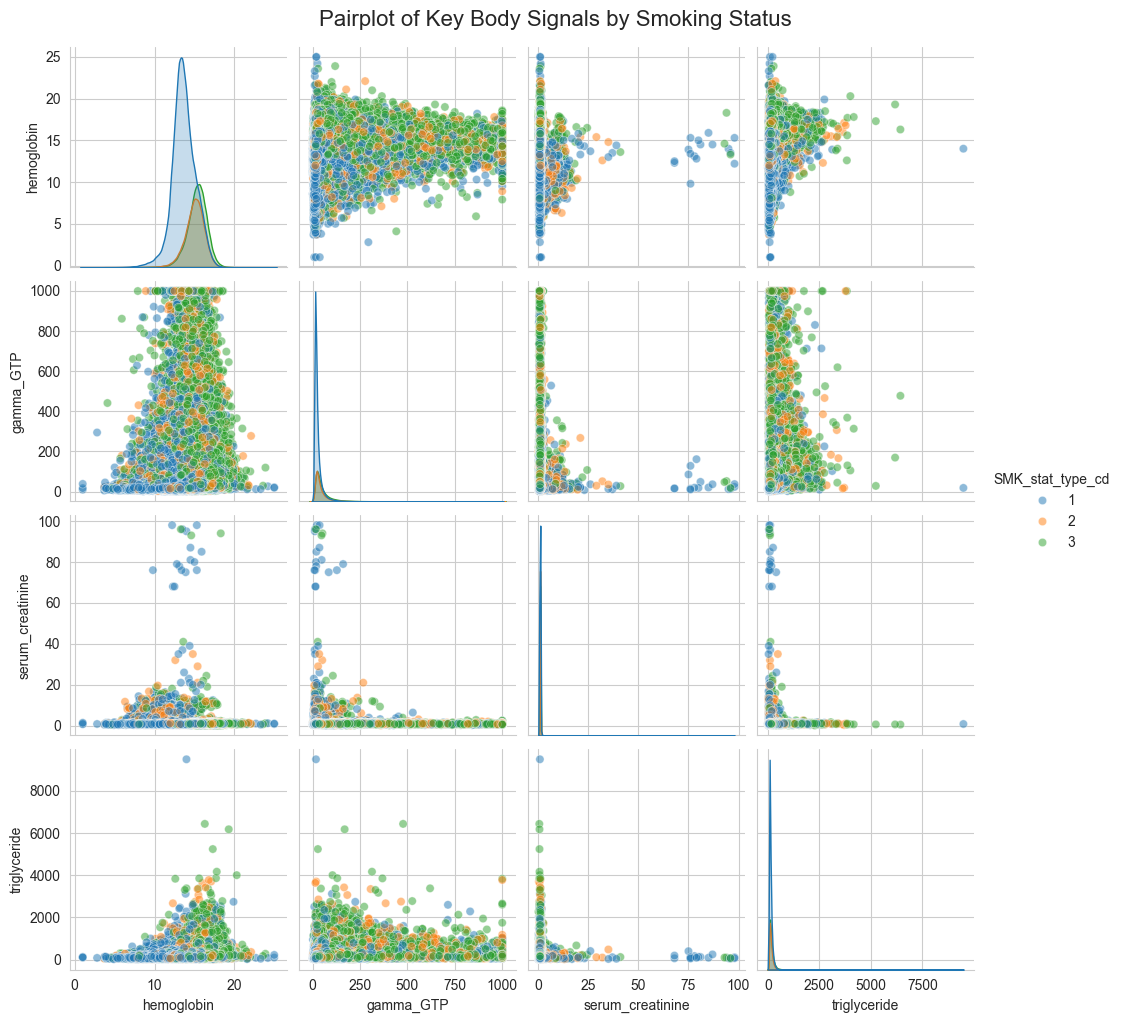

In [24]:
key_features_smokers = ["hemoglobin", "gamma_GTP", "serum_creatinine", "triglyceride", "SMK_stat_type_cd"]

sns.pairplot(
    df_smk_drnk[key_features_smokers],
    hue="SMK_stat_type_cd",
    palette="tab10",
    diag_kind="kde",
    plot_kws={'alpha': 0.5}
)

plt.suptitle("Pairplot of Key Body Signals by Smoking Status", y=1.02, fontsize=16)
plt.show()


### **Outliers**

Outliers are data points that significantly differ from other observations in the dataset. They can be unusually high or low compared to the rest of the data and can arise due to variability in the data or errors in measurement.


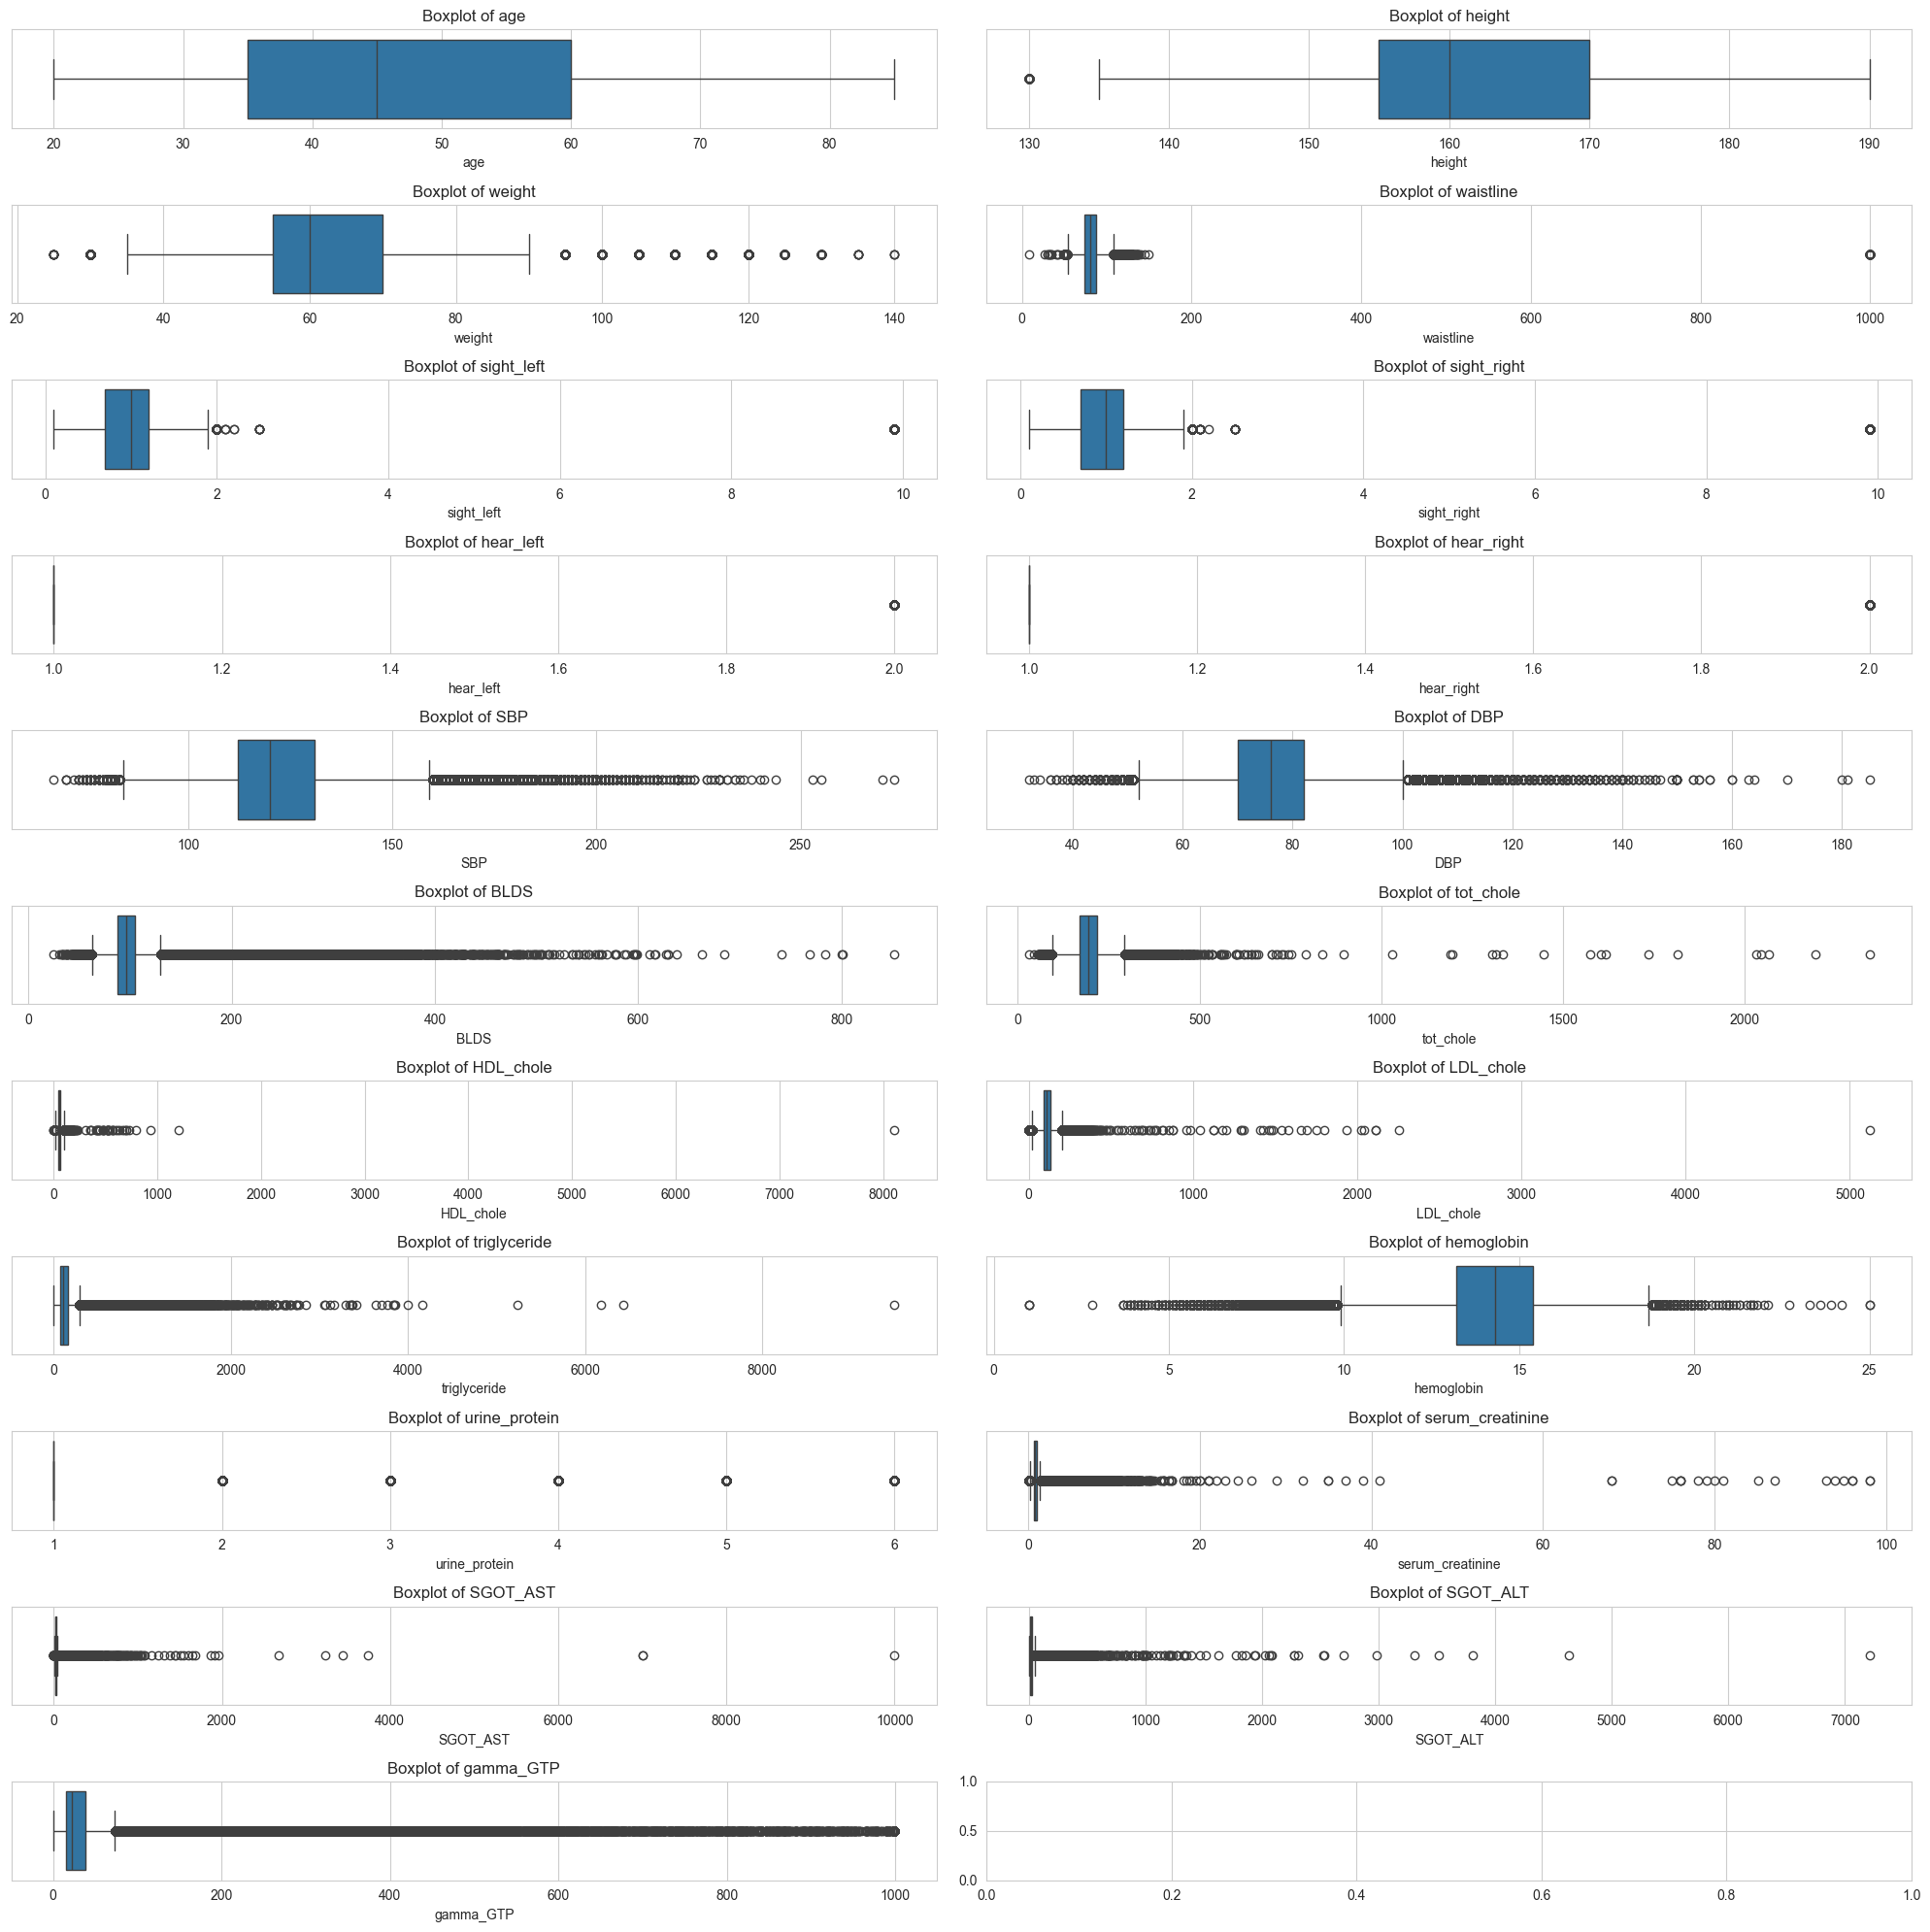

In [25]:
def plot_boxplots(dataframe):
    num_columns = dataframe.select_dtypes(include=['number']).columns
    num_plots = len(num_columns)
    rows = (num_plots + 1) // 2

    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, 20))

    for i, column in enumerate(num_columns):
        row = i // 2
        col = i % 2
        ax = axes[row, col]
        sns.boxplot(x=dataframe[column], ax=ax)
        ax.set_title(f"Boxplot of {column}")
        ax.set_xlabel(column)

    plt.tight_layout()
    plt.show()
plot_boxplots(df_smk_drnk)

**Outlier Detection Using Interquartile Range (IQR)**

- **Technique:** The IQR method was used to detect outliers. It involves calculating the first quartile (Q1) and the third quartile (Q3) of the data for each numeric feature. The interquartile range (IQR) is then calculated as the difference between Q3 and Q1. Outliers are identified as data points that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

- **Reason:** The IQR method is a robust technique that is less sensitive to extreme values than methods based on mean and standard deviation. It is commonly used for datasets that may have non-normal distributions, which is often the case in medical data.

- **Action:** Identified outliers were visualized using boxplots, and their counts were plotted to determine the extent of the issue. Outliers were removed to create a cleaner dataset for further analysis.

In [26]:
# Select only numeric columns for outlier detection
numeric_cols = df_smk_drnk.select_dtypes(include=[np.number]).columns

# Calculate the IQR for each column
Q1 = df_smk_drnk[numeric_cols].quantile(0.25)
Q3 = df_smk_drnk[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define outliers using the IQR method
outliers = ((df_smk_drnk[numeric_cols] < (Q1 - 1.5 * IQR)) | (df_smk_drnk[numeric_cols] > (Q3 + 1.5 * IQR)))

C:\Users\Jdela\AppData\Local\Temp\ipykernel_33340\2196580731.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outlier_count.index, y=outlier_count.values, palette="Set2")


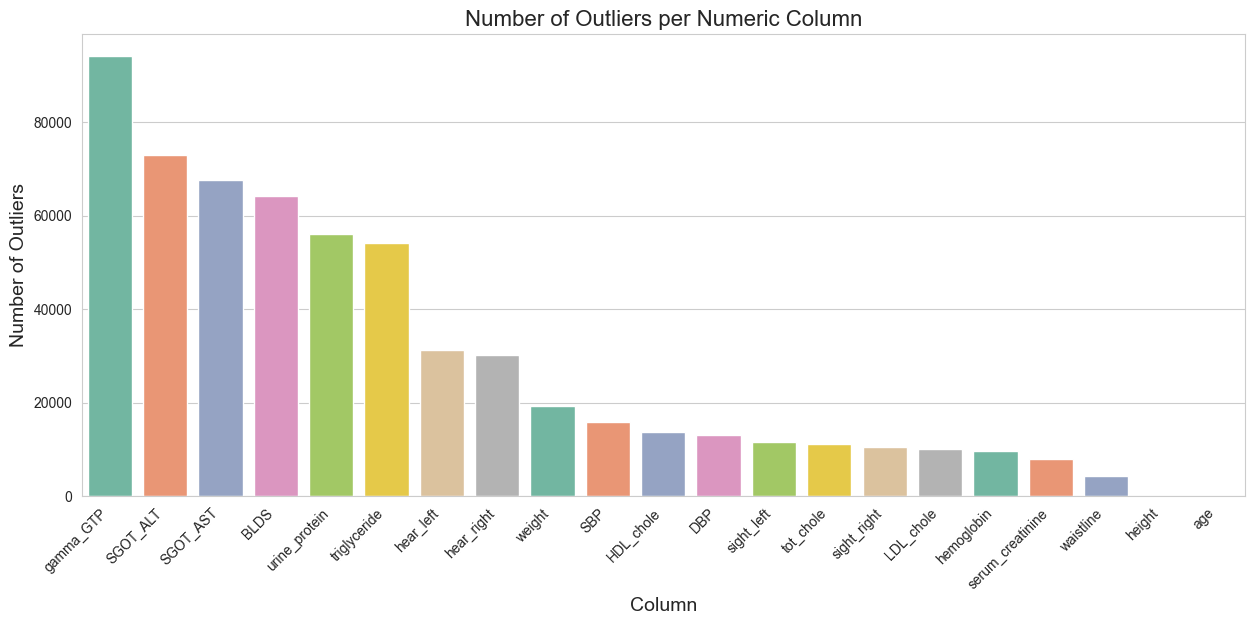

(639442, 24)

In [27]:
# Counting and removing outliers
outlier_count = outliers.sum().sort_values(ascending=False)
df_cleaned = df_smk_drnk.copy()
df_cleaned = df_cleaned[~(outliers.any(axis=1))]

# Plotting the number of outliers per column
plt.figure(figsize=(15, 6))
sns.barplot(x=outlier_count.index, y=outlier_count.values, palette="Set2")
plt.title('Number of Outliers per Numeric Column', fontsize=16)
plt.xlabel('Column', fontsize=14)
plt.ylabel('Number of Outliers', fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.show()

df_cleaned.shape

### **Check missing values and duplicates**

There are no missing values in the dataset

In [28]:
print((df_cleaned.isnull().sum() / len(df_cleaned)) * 100)

sex                 0.0
age                 0.0
height              0.0
weight              0.0
waistline           0.0
sight_left          0.0
sight_right         0.0
hear_left           0.0
hear_right          0.0
SBP                 0.0
DBP                 0.0
BLDS                0.0
tot_chole           0.0
HDL_chole           0.0
LDL_chole           0.0
triglyceride        0.0
hemoglobin          0.0
urine_protein       0.0
serum_creatinine    0.0
SGOT_AST            0.0
SGOT_ALT            0.0
gamma_GTP           0.0
SMK_stat_type_cd    0.0
DRK_YN              0.0
dtype: float64


checking and elimination of duplicates in the dataset

In [29]:
print(df_cleaned[df_cleaned.duplicated()])

       sex  age  height  weight  waistline  sight_left  sight_right  \
159911   F   40     170      85       88.0         0.9          0.9   
175152   M   65     170      75      101.1         0.6          0.7   
246305   F   50     155      70       90.8         1.0          1.0   
284528   F   65     150      55       86.0         0.9          0.9   
290463   F   20     160      50       70.0         1.0          1.0   
453451   M   35     170      65       85.0         0.9          1.2   
471596   F   45     165      65       82.0         1.0          1.0   
479756   M   50     165      65       77.0         0.8          1.0   
558263   F   65     145      50       76.0         1.0          0.9   
568854   M   50     170      65       87.8         1.5          1.5   
671067   M   60     165      70       84.0         0.4          0.1   
727207   M   40     170      70       82.0         0.8          1.5   
746077   M   25     180      70       76.0         1.0          1.2   
834790

In [30]:
num_duplicated = df_cleaned.duplicated().sum()
print(f'Number of duplicate rows: {num_duplicated}')

Number of duplicate rows: 14


In [31]:
df_cleaned.drop_duplicates(inplace=True)
num_duplicated = df_cleaned.duplicated().sum()
print(f'Number of duplicate rows: {num_duplicated}')

Number of duplicate rows: 0


# **Migration**

In [ ]:
import google.oauth2.service_account as service_account
import pandas_gbq
from google.cloud import bigquery
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
# Conversion of categorical columns
df_cleaned['sex'] = df_cleaned['sex'].astype(str)  # Conversion to string for BigQuery
df_cleaned['DRK_YN'] = df_cleaned['DRK_YN'].astype(str)

# Conversion of 'SMK_stat_type_cd' to integer
df_cleaned['SMK_stat_type_cd'] = pd.to_numeric(df_cleaned['SMK_stat_type_cd'], downcast='integer')

# Data preprocessing
# Convert categorical columns to numerical values
label_encoder = LabelEncoder()
df_cleaned['sex'] = label_encoder.fit_transform(df_cleaned['sex'])  # Male: 1, Female: 0
df_cleaned['DRK_YN'] = label_encoder.fit_transform(df_cleaned['DRK_YN'])  # Y: 1, N: 0

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 639428 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               639428 non-null  int64  
 1   age               639428 non-null  int64  
 2   height            639428 non-null  int64  
 3   weight            639428 non-null  int64  
 4   waistline         639428 non-null  float64
 5   sight_left        639428 non-null  float64
 6   sight_right       639428 non-null  float64
 7   hear_left         639428 non-null  float64
 8   hear_right        639428 non-null  float64
 9   SBP               639428 non-null  float64
 10  DBP               639428 non-null  float64
 11  BLDS              639428 non-null  float64
 12  tot_chole         639428 non-null  float64
 13  HDL_chole         639428 non-null  float64
 14  LDL_chole         639428 non-null  float64
 15  triglyceride      639428 non-null  float64
 16  hemoglobin        639428 

In [ ]:
credentials = service_account.Credentials.from_service_account_file('projectdm-442203-d65d326d147d.json')

project = 'projectdm-442203'

In [ ]:
client = bigquery.Client(credentials=credentials, project=project)

# Listar datasets del proyecto
datasets = list(client.list_datasets())

In [ ]:
datasets

In [ ]:
pandas_gbq.to_gbq(
    df_cleaned,
    'projectdm-442203.Dataset.df_smk_drkn',  # Solo dataset y tabla
    project_id=project,
    if_exists='replace',
    credentials=credentials
)

# **Model**

For this task, the RandomForestClassifier was selected due to its robustness and ability to handle a large number of features effectively.

## **BigQuery Data Retrieval**

In [ ]:
client = bigquery.Client(credentials=credentials, project=project)

query = f"""
    SELECT *
    FROM `Dataset.df_smk_drkn`
"""

# Ejecutar la consulta
query_job = client.query(query)
df_smk_drk = query_job.result().to_dataframe()

# Cerrar la conexión al cliente
client.close()

# Mostrar los resultados
df_smk_drk

/home/davnpsh/University/Semestre 8/MINERIA DE DATOS/Proyecto final/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1727: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,0,80,135,40,79.0,0.8,0.7,1.0,1.0,149.0,...,84.0,157.0,10.0,1.0,1.1,20.0,18.0,24.0,1,0
1,0,80,135,45,77.0,0.1,0.4,1.0,1.0,143.0,...,106.0,126.0,10.0,1.0,1.2,33.0,20.0,16.0,1,0
2,0,80,135,35,91.0,0.8,0.8,1.0,1.0,120.0,...,130.0,79.0,10.0,1.0,0.7,15.0,10.0,22.0,1,0
3,0,85,135,40,89.0,0.7,0.7,1.0,1.0,138.0,...,110.0,55.0,10.0,1.0,0.7,19.0,10.0,15.0,1,0
4,0,75,135,55,99.0,0.3,0.4,1.0,1.0,146.0,...,56.0,96.0,10.0,1.0,0.7,11.0,6.0,16.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
639423,1,30,190,90,96.0,1.5,1.5,1.0,1.0,151.0,...,135.0,146.0,15.9,1.0,0.9,21.0,26.0,36.0,1,1
639424,1,30,190,85,79.0,0.9,0.7,1.0,1.0,140.0,...,106.0,84.0,15.9,1.0,1.0,25.0,19.0,26.0,1,1
639425,1,40,190,85,86.0,1.2,1.0,1.0,1.0,122.0,...,116.0,90.0,15.9,1.0,0.9,23.0,21.0,25.0,2,1
639426,1,30,190,75,85.0,1.0,0.7,1.0,1.0,112.0,...,72.0,94.0,15.9,1.0,0.9,14.0,18.0,16.0,1,0


## 2. Training

### Data Splitting

The dataset was split into **training (70%)** and **test (30%)** sets using `train_test_split` with stratification to maintain the balance of classes in both sets.

### Model Training

- **Training Data:** The training data was used to fit the **RandomForestClassifier**.
- **Feature Scaling:** We applied **StandardScaler** to ensure all features were on the same scale.

### Computational Resources

The training was conducted on **Google Colab**, which provided ample CPU resources for model training.

## Stratified 10-Fold Cross-Validation

To evaluate the model's performance effectively, we implemented **Stratified 10-Fold Cross-Validation**. This method was chosen specifically to maintain the class distribution across each fold, which is crucial when dealing with imbalanced datasets. By ensuring that each training and testing set reflects the overall class distribution, we can mitigate potential biases and improve the reliability of our model evaluation.


In [ ]:
# Import necessary libraries
import google.oauth2.service_account as service_account
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

In [ ]:
df = df_smk_drk.copy()
credentials = service_account.Credentials.from_service_account_file("projectdm-442203-d65d326d147d.json")
project = 'projectdm-442203'

In [ ]:
def train_model(df, target_col, model_name):

    X = df.drop(columns=['SMK_stat_type_cd', 'DRK_YN'])  # Features (excluding target variables)
    y = df[target_col]  # Target (smoking or drinking)

    # Split data into training and test sets (70% training, 30% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize RandomForestClassifier
    rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, min_samples_split=5)

    # Train the model
    rf_model.fit(X_train_scaled, y_train)

    # Model Evaluation on the test set
    y_pred = rf_model.predict(X_test_scaled)

    # Performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Print formatted results
    print(f'# {model_name} Classification Results\n')
    print(f'**Accuracy:** {accuracy:.3f}')
    print(f'**Precision:** {precision:.3f}')
    print(f'**Recall:** {recall:.3f}')
    print(f'**F1-Score:** {f1:.3f}\n')

    print(f'## Classification Report:')
    print(classification_report(y_test, y_pred))

    # Cross-validation with StratifiedKFold
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

    # Print cross-validation results
    print(f'## Cross-Validation Accuracy Scores: {cv_scores}')
    print(f'**Mean CV Accuracy:** {np.mean(cv_scores):.3f}\n')

    # Return model, confusion matrix, test labels, and unscaled X_train for feature importance
    return rf_model, conf_matrix, y_test, X_train

In [ ]:
def plot_confusion_matrix(conf_matrix, y_test, model_name):
    plt.figure(figsize=(8, 6))

    if model_name == 'Smoking Status':
        labels = ['Never', 'Used to Smoke but Quit', 'Still Smoke']
    elif model_name == 'Drinking Status':
        labels = ['No', 'Yes']
    else:
        labels = np.unique(y_test)

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('True', fontsize=14)
    plt.show()

In [ ]:
def plot_feature_importance(rf_model, X_train, model_name):
    feature_importance = rf_model.feature_importances_
    features = X_train.columns if isinstance(X_train, pd.DataFrame) else range(X_train.shape[1])

    # Create a DataFrame to plot feature importance
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'{model_name} - Feature Importance')
    plt.gca().invert_yaxis()
    plt.show()

#### Smoking Status

In [ ]:
rf_model_smk, conf_matrix_smk, y_test_smk, X_train_smk = train_model(df, target_col='SMK_stat_type_cd', model_name='Smoking Status')

# Smoking Status Classification Results

**Accuracy:** 0.721
**Precision:** 0.590
**Recall:** 0.579
**F1-Score:** 0.583

## Classification Report:
              precision    recall  f1-score   support

         1.0       0.84      0.86      0.85    126741
         2.0       0.45      0.36      0.40     29950
         3.0       0.49      0.51      0.50     35138

    accuracy                           0.72    191829
   macro avg       0.59      0.58      0.58    191829
weighted avg       0.71      0.72      0.72    191829

## Cross-Validation Accuracy Scores: [0.72062109 0.72017426 0.72231903 0.71899017 0.7169571  0.72115728
 0.71925827 0.71624218 0.71919124 0.72097232]
**Mean CV Accuracy:** 0.720



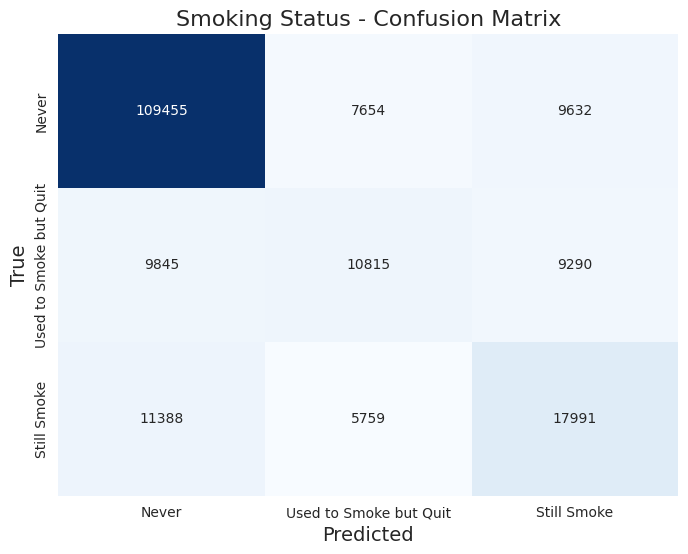

In [ ]:
plot_confusion_matrix(conf_matrix_smk, y_test_smk, 'Smoking Status')

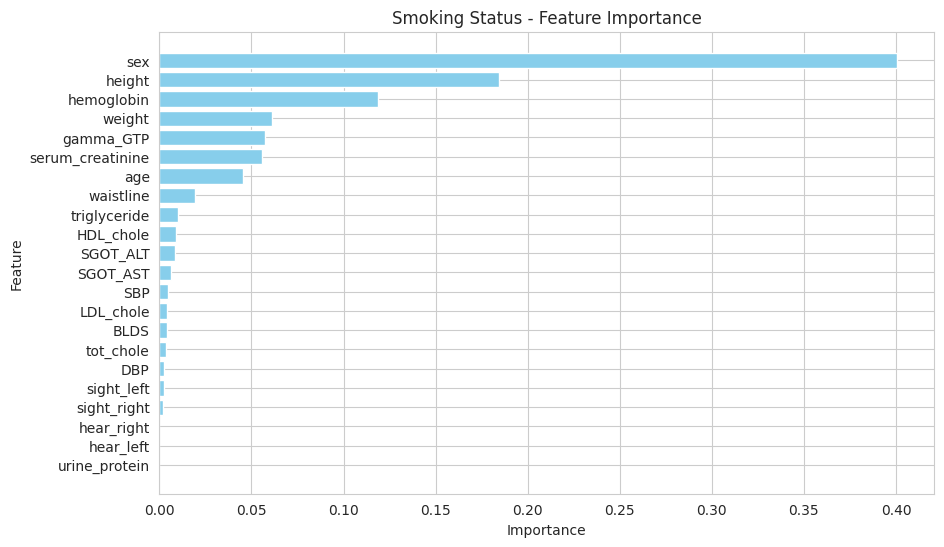

In [ ]:
plot_feature_importance(rf_model_smk, X_train_smk, 'Smoking Status')

#### Drinking Status

In [ ]:
rf_model_drk, conf_matrix_drk, y_test_drk, X_train_drk = train_model(df, target_col='DRK_YN', model_name='Drinking Status')

# Drinking Status Classification Results

**Accuracy:** 0.709
**Precision:** 0.709
**Recall:** 0.709
**F1-Score:** 0.709

## Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.72      0.72    100976
         1.0       0.69      0.70      0.69     90853

    accuracy                           0.71    191829
   macro avg       0.71      0.71      0.71    191829
weighted avg       0.71      0.71      0.71    191829

## Cross-Validation Accuracy Scores: [0.70828865 0.70976318 0.70989723 0.70781948 0.70958445 0.70735031
 0.70504915 0.70592046 0.70607685 0.70703099]
**Mean CV Accuracy:** 0.708



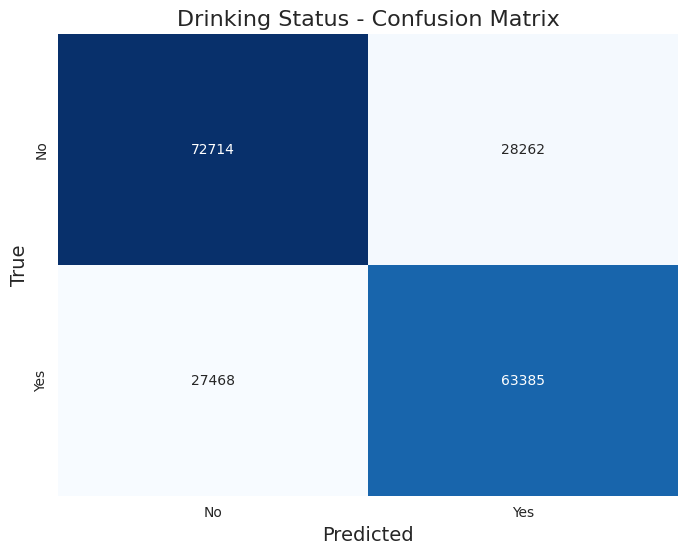

In [ ]:
plot_confusion_matrix(conf_matrix_drk, y_test_drk, 'Drinking Status')

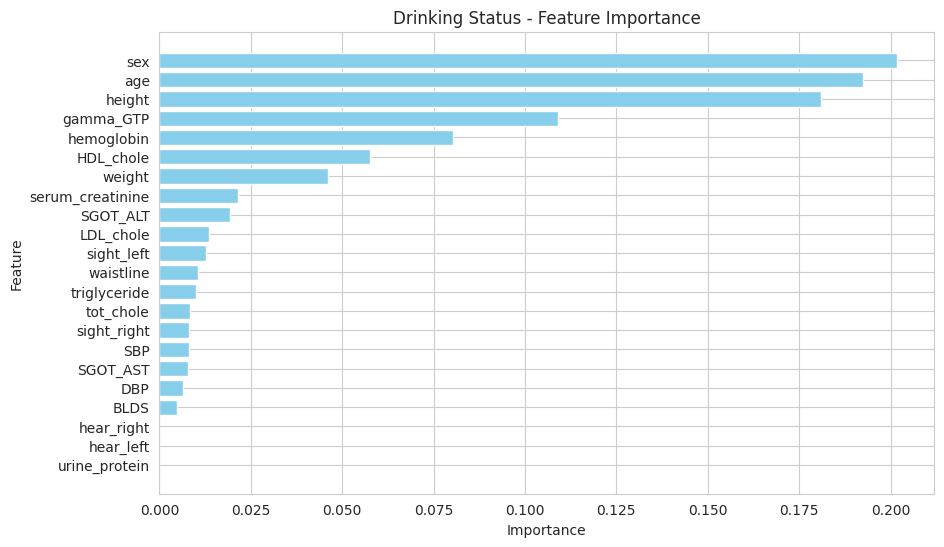

In [ ]:
plot_feature_importance(rf_model_drk, X_train_drk, 'Drinking Status')

## HyperParameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from datetime import datetime

def timer(start_time=None):
    if not start_time:
        start_time = datetime.now()
        return start_time
    else:
        thour, temp_sec = divmod((datetime.now() - start_time).total_seconds(), 3600)
        tmin, tsec = divmod(temp_sec, 60)
        print('\nTime taken: %i hours %i minutes and %s seconds.' % (thour, tmin, round(tsec, 2)))

def tuning(df, target_col, n_iter=20):
    """
    Train a Random Forest model with hyperparameter tuning using a subset of data.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe containing features and target
    target_col : str
        Name of the target column
    n_iter : int, optional
        Number of parameter combinations to try in random search

    Returns:
    --------
    dict
        Dictionary containing the best parameters
    """

    # Separate features and target
    list_of_columns = df.columns.tolist()
    list_of_columns.remove(target_col)
    feature_cols = list_of_columns

    # Use a 30% sample of the df for tuning
    df_sample = df.sample(frac=0.4, random_state=42)

    X = df_sample[feature_cols]
    y = df_sample[target_col]

    # Split data for training the hyperparameter tuning model
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Parameter grid for Random Forest
    params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

    # Initialize Random Forest
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    # Setup cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=params,
        n_iter=n_iter,
        scoring='accuracy',  # Can adjust scoring if desired
        n_jobs=-1,
        cv=skf.split(X_train, y_train),
        verbose=1,
        random_state=42
    )

    # Start timing and fit
    print("Starting parameter search...")
    start_time = timer()
    random_search.fit(X_train, y_train)
    timer(start_time)

    # Return only the best parameters
    return {
        'best_params': random_search.best_params_
    }


### Smoking

In [ ]:
df.columns

Index(['sex', 'age', 'height', 'weight', 'waistline', 'sight_left',
       'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS',
       'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin',
       'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT',
       'gamma_GTP', 'SMK_stat_type_cd', 'DRK_YN'],
      dtype='object')

In [ ]:
# Select important features for smoking classification
important_features_smoking = ['sex', 'height', 'hemoglobin', 'weight', 'gamma_GTP', 'serum_creatinine', 'age', "waistline","triglyceride","HDL_chole", "SGOT_ALT","SGOT_AST"]

# Create a new DataFrame with only the important features and the target variable
df_smoking_important = df[important_features_smoking + ['SMK_stat_type_cd']]

best_params_smoking = tuning(df_smoking_important, target_col='SMK_stat_type_cd')

best_params_smoking

Starting parameter search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/home/davnpsh/University/Semestre 8/MINERIA DE DATOS/Proyecto final/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Time taken: 0 hours 19 minutes and 23.08 seconds.


{'best_params': {'n_estimators': 300,
  'min_samples_split': 5,
  'min_samples_leaf': 4,
  'max_features': 'log2',
  'max_depth': 10,
  'class_weight': None,
  'bootstrap': True}}

### Drinking

In [ ]:
important_features_drinking = ["sex","age", "height","gamma_GTP","hemoglobin","HDL_chole", "weight", "serum_creatinine", "SGOT_ALT", "LDL_chole", "sight_left", "waistline"]
df_drinking_important = df[important_features_drinking + ['DRK_YN']]

best_params_drinking = tuning(df_drinking_important, target_col='DRK_YN')

best_params_drinking


Starting parameter search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/home/davnpsh/University/Semestre 8/MINERIA DE DATOS/Proyecto final/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Time taken: 0 hours 18 minutes and 35.05 seconds.


{'best_params': {'n_estimators': 300,
  'min_samples_split': 5,
  'min_samples_leaf': 4,
  'max_features': 'log2',
  'max_depth': None,
  'class_weight': None,
  'bootstrap': True}}

## **Smoking Status**

Classification Results Analysis

The evaluation of the smoking status classification model yielded the following metrics:

- **Accuracy:** 0.721
- **Precision:** 0.590
- **Recall:** 0.579
- **F1-Score:** 0.583

## Classification Report
                                    precision   recall  f1-score   support

     1.0 (never)                      0.84      0.86      0.85    126741
     2.0 (used to smoke but quit)     0.45      0.36      0.40     29950
     3.0 (still smoke)                0.49      0.51      0.50     35138

**Mean Cross Validation Accuracy:** 72%

## Feature Importance

The most important features identified for predicting smoking status are:

- **Sex**
- **Height**
- **Hemoglobin**
- **Weight**
- **Gamma-GTP**
- **Serum Creatinine**
- **Age**

These features play a significant role in the model's decision-making process, indicating that biological and demographic factors are crucial in assessing smoking status.

## Insights and Discrepancies

The model achieved an overall accuracy of 72.1%, which is indicative of a decent performance in classifying smoking status. However, the precision and recall metrics reveal some important insights:

1. **Class Imbalance:** The model performs significantly better for the first class (smoking status 1.0) with a precision of 0.84 and a recall of 0.86. This suggests that the model is effective in identifying non-smokers. However, the lower precision (0.45) and recall (0.36) for the second class (status 2.0) indicate that it struggles to accurately classify occasional smokers. The performance for the third class (status 3.0) is slightly better but still lacks robustness (precision: 0.49, recall: 0.51).

2. **F1-Score Analysis:** The F1-scores highlight the trade-offs between precision and recall for different classes. The first class achieves an F1-score of 0.85, while the second and third classes only achieve 0.40 and 0.50, respectively. This suggests that while the model is reliable for the majority class, it is not performing well for the minority classes.

3. **Cross-Validation Consistency:** The mean cross-validation accuracy of 72.0% corroborates the overall accuracy, indicating that the model's performance is consistent across different subsets of the data. However, the variability in the scores suggests there might be fluctuations in performance depending on the specific data split used.

In summary, while the smoking status classification model shows promise, particularly in identifying non-smokers, there are significant challenges in accurately classifying occasional and heavy smokers. Addressing class imbalance, perhaps through techniques like oversampling, undersampling, or model adjustments, could help improve the model's performance across all classes.


In [ ]:
X = df.drop(columns=['SMK_stat_type_cd', 'DRK_YN'])  # Features (excluding target variables)
y = df["SMK_stat_type_cd"]  # Target (smoking or drinking)

# Split data into training and test sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
best_params = best_params_smoking['best_params']

rf_smoking = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    bootstrap=best_params['bootstrap'],
    class_weight=best_params['class_weight'],
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_smoking.fit(X_train_scaled, y_train)

# Model Evaluation on the test set
y_pred = rf_smoking.predict(X_test_scaled)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# Confusion matrix
conf_matrix_smoking = confusion_matrix(y_test, y_pred)

# Print formatted results
print(f'# {"Smoking"} Classification Results\n')
print(f'**Accuracy:** {accuracy:.3f}')
print(f'**Precision:** {precision:.3f}')
print(f'**Recall:** {recall:.3f}')
print(f'**F1-Score:** {f1:.3f}\n')

print(f'## Classification Report:')
print(classification_report(y_test, y_pred))

# Cross-validation with StratifiedKFold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_smoking, X_train_scaled, y_train, cv=cv, scoring='accuracy')

# Print cross-validation results
print(f'## Cross-Validation Accuracy Scores: {cv_scores}')
print(f'**Mean CV Accuracy:** {np.mean(cv_scores):.3f}\n')

# Smoking Classification Results

**Accuracy:** 0.721
**Precision:** 0.591
**Recall:** 0.578
**F1-Score:** 0.583

## Classification Report:
              precision    recall  f1-score   support

         1.0       0.84      0.87      0.85    126741
         2.0       0.45      0.36      0.40     29950
         3.0       0.49      0.51      0.50     35138

    accuracy                           0.72    191829
   macro avg       0.59      0.58      0.58    191829
weighted avg       0.71      0.72      0.72    191829

## Cross-Validation Accuracy Scores: [0.72004021 0.7204647  0.72287757 0.71970509 0.71785076 0.72033065
 0.72010724 0.71726988 0.72015192 0.72092763]
**Mean CV Accuracy:** 0.720



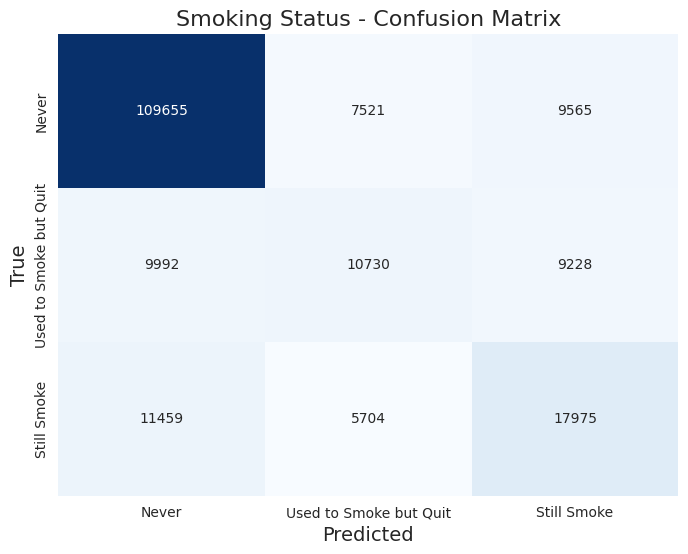

In [ ]:
plot_confusion_matrix(conf_matrix_smoking, y_test, 'Smoking Status')

## Drinking Status Classification Results Analysis

The evaluation of the drinking status classification model yielded the following metrics:

- **Accuracy:** 0.712
- **Precision:** 0.711
- **Recall:** 0.711
- **F1-Score:** 0.711

## Classification Report

                precision  recall  f1-score   support

     0.0 (No)     0.72      0.74      0.73    100976
     1.0 (yes)    0.70      0.69      0.69     90853

**Mean Cross Validation Accuracy:** 71%

## Feature Importance

The most important features identified for predicting drinking status are:

- **Gamma-GTP**
- **Age**
- **Hemoglobin**
- **HDL Cholesterol**
- **Triglycerides**
- **Height**
- **LDL Cholesterol**

These features play a significant role in the model's decision-making process, suggesting that biological and lifestyle factors are crucial in assessing drinking status.

## Insights and Discrepancies

The model achieved an overall accuracy of 71.2%, indicating a solid performance in classifying drinking status. The metrics reveal several key insights:

1. **Balanced Performance:** The precision, recall, and F1-scores are all approximately equal across both classes, reflecting a balanced performance between non-drinkers (0.0) and drinkers (1.0). Specifically, the model shows a precision of 0.72 and recall of 0.74 for non-drinkers, while for drinkers, the precision is 0.70 and recall is 0.69. This suggests that the model is fairly reliable for both categories.

2. **F1-Score Consistency:** The F1-scores are also close to each other, with 0.73 for non-drinkers and 0.69 for drinkers. This consistency indicates that the model maintains a good balance between false positives and false negatives across both classes.

3. **Cross-Validation Results:** The mean cross-validation accuracy of 71.0% aligns closely with the overall accuracy, suggesting that the model’s performance is stable across different subsets of the data. The slight fluctuations in individual cross-validation scores (ranging from 0.706 to 0.712) indicate a reliable but slightly sensitive model, potentially influenced by the distribution of classes in each fold.

4. **Class Support:** The support for each class indicates that the dataset has a higher number of non-drinkers (100976) compared to drinkers (90853). This could suggest a potential class imbalance issue that may affect the model's performance in real-world applications, although the metrics do not currently indicate severe bias.

In conclusion, the drinking status classification model demonstrates solid performance, especially in distinguishing between non-drinkers and drinkers. However, continued monitoring and possibly addressing any latent class imbalance through data augmentation or model tuning could further enhance the model's robustness and predictive capability.


In [ ]:
X = df.drop(columns=['SMK_stat_type_cd', 'DRK_YN'])  # Features (excluding target variables)
y = df["DRK_YN"]  # Target (smoking or drinking)

# Split data into training and test sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
best_params_drinking = best_params_drinking['best_params']

rf_drinking = RandomForestClassifier(
    n_estimators=best_params_drinking['n_estimators'],
    max_depth=best_params_drinking['max_depth'],
    min_samples_split=best_params_drinking['min_samples_split'],
    min_samples_leaf=best_params_drinking['min_samples_leaf'],
    max_features=best_params_drinking['max_features'],
    bootstrap=best_params_drinking['bootstrap'],
    random_state=42,
    n_jobs=-1

)

# Train the model
rf_drinking.fit(X_train_scaled, y_train)

# Model Evaluation on the test set
y_pred = rf_drinking.predict(X_test_scaled)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# Confusion matrix
conf_matrix_drinking = confusion_matrix(y_test, y_pred)

# Print formatted results
print(f'# {"Drinking"} Classification Results\n')
print(f'**Accuracy:** {accuracy:.3f}')
print(f'**Precision:** {precision:.3f}')
print(f'**Recall:** {recall:.3f}')
print(f'**F1-Score:** {f1:.3f}\n')

print(f'## Classification Report:')
print(classification_report(y_test, y_pred))

# Cross-validation with StratifiedKFold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_drinking, X_train_scaled, y_train, cv=cv, scoring='accuracy')

# Print cross-validation results
print(f'## Cross-Validation Accuracy Scores: {cv_scores}')
print(f'**Mean CV Accuracy:** {np.mean(cv_scores):.3f}\n')

# Drinking Classification Results

**Accuracy:** 0.716
**Precision:** 0.715
**Recall:** 0.715
**F1-Score:** 0.715

## Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.73      0.73    100976
         1.0       0.70      0.70      0.70     90853

    accuracy                           0.72    191829
   macro avg       0.72      0.72      0.72    191829
weighted avg       0.72      0.72      0.72    191829

## Cross-Validation Accuracy Scores: [0.71423146 0.71713584 0.71456658 0.71416443 0.71525916 0.71394102
 0.71251117 0.71389634 0.71134942 0.71353247]
**Mean CV Accuracy:** 0.714



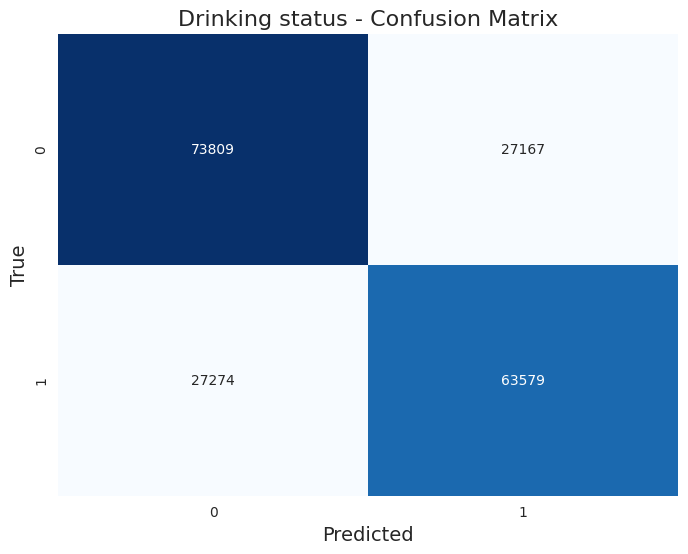

In [ ]:
plot_confusion_matrix(conf_matrix_drinking, y_test, 'Drinking status')